# NYC Taxi Fare Amount — Baseline Modeling
  - Caleb Solomons
  - Mubeen Yaqub
  - Mai Lam
  - Anh Minh Tran


**DSCI 592 Capstone — Team GridRunners**
**Target:** `fare_amount` (regression)
**Models:** Linear Regression (baseline) vs. XGBoost
**Sample:** ~1.5M rows, stratified on `pickup_hour × pickup_borough`


Metrics comparison table (RMSE / MAE / R2)
Predicted-vs-actual scatter (XGBoost)
Feature importance bar chart (XGBoost, aggregated to source features)

Residuals plot as a secondary artifact.

> **Edit the marked cells** (`# >>> EDIT <<<`) to match your Drive paths and the actual column names from your DSCI 591 cleaned parquet.


## 1. Setup

In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import xgboost as xgb

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"

sns.set_style("whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__}")


pandas 2.2.2 | numpy 2.0.2 | xgboost 3.2.0


## 2. Mount Drive & Set Paths

**Edit `DRIVE_BASE` and `DATA_PATH`** to match where your cleaned parquet.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


# >>> EDIT <<<  Paths

#                          >>VV EDIT ME VV<<
DRIVE_BASE  = Path("/content/drive/MyDrive/DSCI 592")

# DRIVE_BASE = Path("./DSCI_592")              # plain local fallback
#DATA_PATH   = DRIVE_BASE / "data" / "2023_Yellow_Taxi_Cleaned.parquet"

#                                        >>VV EDIT ME VV<<
DATA_PATH = Path("/content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet")

OUTPUT_DIR  = DRIVE_BASE / "baseline_fare"
FIGURE_DIR  = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"

for d in (OUTPUT_DIR, FIGURE_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Reading data from : {DATA_PATH}")
print(f"Saving outputs to : {OUTPUT_DIR}")


Mounted at /content/drive
Reading data from : /content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet
Saving outputs to : /content/drive/MyDrive/DSCI 592/baseline_fare


## 3. Load Data & Inspect Columns

In [ ]:
df_full = pd.read_parquet(DATA_PATH)

print(f"Full dataset shape : {df_full.shape[0]:,} rows × {df_full.shape[1]} cols")
print(f"Memory footprint   : {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB\n")
print("Columns and dtypes:")
print(df_full.dtypes.to_string())


Full dataset shape : 37,017,621 rows × 35 cols
Memory footprint   : 29.12 GB

Columns and dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration_min               float64
speed_mph                       float64
pickup_hour                       int32
pickup_dow            

## 4. Feature Selection — With Leakage Discipline

> Both *pre-trip* and *post-trip* fields. For fare prediction to be valid as a real-world model, **only features that would be known at the moment a trip is requested**.

**Pre-trip features (use):**
- `trip_distance` — from a routing API estimating pickup→dropoff distance; for this baseline use recorded value.
- `passenger_count`
- Pickup time features: hour, day-of-week, weekend flag.
- Pickup & dropoff borough.
- `VendorID`

**Leaky features (exclude):**
- `tip_amount`, `tolls_amount`, `total_amount`, `mta_tax`, `congestion_surcharge`, `airport_fee`, `improvement_surcharge`, `extra` — all components of the final receipt.
- `trip_duration` — not known until the trip ends. Same for `average_speed`.
- `payment_type` — typically chosen at trip end.
- `tpep_dropoff_datetime` — drop end-time too.


In [ ]:
COL = {
    "target":        "fare_amount",
    "trip_distance": "trip_distance",
    "passengers":    "passenger_count",
    "hour":          "pickup_hour",
    "dow":           "pickup_dow",
    "weekend":       "is_weekend",
    "pu_borough":    "PU_borough",
    "do_borough":    "DO_borough",
    "vendor":        "VendorID",
}

NUMERIC_FEATURES = [COL["trip_distance"], COL["passengers"]]
CATEGORICAL_FEATURES = [COL["hour"], COL["dow"], COL["weekend"],
                        COL["pu_borough"], COL["do_borough"], COL["vendor"]]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = COL["target"]



needed = set(ALL_FEATURES + [TARGET, COL["hour"], COL["pu_borough"]])
missing = sorted(needed - set(df_full.columns))

if missing:
    raise KeyError(
        f"These columns are missing from the parquet — fix the COL mapping above: {missing}"
    )

print("All expected columns present. Proceeding.")


All expected columns present. Proceeding.


## 5. Filter


In [ ]:
# >>> EDIT <<<  Bounds — set these to whatever

FARE_MIN, FARE_MAX = 2.5, 250.0   # NYC base fare floor -> generous airport-trip ceiling
DIST_MIN, DIST_MAX = 0.1, 60.0    # miles

mask = (
    df_full[TARGET].between(FARE_MIN, FARE_MAX)
    & df_full[COL["trip_distance"]].between(DIST_MIN, DIST_MAX)
    & df_full[ALL_FEATURES + [TARGET]].notna().all(axis=1)
)


# don't re-add  hour and pu_borough — that would create duplicate columns
# and break any downstream `df_clean[colname]` access that expects a Series.

df_clean = df_full.loc[mask, ALL_FEATURES + [TARGET]].copy()

print(f"Rows dropped by sanity filter : {(~mask).sum():,} ({(~mask).mean():.2%})")
print(f"Rows remaining                : {len(df_clean):,}")


Rows dropped by sanity filter : 1,724,561 (4.66%)
Rows remaining                : 35,293,060


## 6. Stratified Sample — `pickup_hour × pickup_borough`

Sample ~1.5M rows proportionally across the 24 × |boroughs| strata. This keeps temporal-spatial balance while making model training tractable. Bump `SAMPLE_SIZE` up later for full-dataset run.


In [ ]:
SAMPLE_SIZE = 1_500_000


# strata key, combine hour and pickup borough

df_clean["_strat"] = (
    df_clean[COL["hour"]].astype(str) + "|" + df_clean[COL["pu_borough"]].astype(str)
)

frac = min(1.0, SAMPLE_SIZE / len(df_clean))

print(f"Sampling fraction: {frac:.4f}")


# group_keys=False keeps the resulting frame flat

sample = (
    df_clean
    .groupby("_strat", group_keys=False)
    .apply(lambda g: g.sample(frac=frac, random_state=SEED))
    .reset_index(drop=True)
)

print(f"Sample shape: {sample.shape[0]:,} rows × {sample.shape[1]} cols")
print(f"Stratum count: {sample['_strat'].nunique()}")


Sampling fraction: 0.0425
Sample shape: 1,499,995 rows × 10 cols
Stratum count: 147


## 7. Train/Test Split

80/20, stratified on the same hour×borough key so the test set keeps the same temporal-spatial mix.


In [ ]:
X = sample[ALL_FEATURES].copy()
y = sample[TARGET].copy()



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
)

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"Target mean (train): ${y_train.mean():.2f} | (test): ${y_test.mean():.2f}")


Train : 1,199,996 rows
Test  : 299,999 rows
Target mean (train): $19.39 | (test): $19.36


## 8. Preprocessing Pipeline

`ColumnTransformer` with:
- **Numerics** → `StandardScaler` (matters for Linear; benign for XGBoost).
- **Categoricals** → `OneHotEncoder(handle_unknown='ignore')` so test-set categories not seen at fit time don't crash inference.

Use the same transformer for both models for an apples-to-apples comparison.


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)


## 9. Model 1 — Linear Regression Baseline

In [ ]:
linear_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression()),
])

linear_pipe.fit(X_train, y_train)
y_pred_lin = linear_pipe.predict(X_test)


rmse_lin = float(np.sqrt(mean_squared_error(y_test, y_pred_lin)))
mae_lin  = float(mean_absolute_error(y_test, y_pred_lin))
r2_lin   = float(r2_score(y_test, y_pred_lin))

print(f"Linear Regression — RMSE: ${rmse_lin:.3f} | MAE: ${mae_lin:.3f} | R²: {r2_lin:.4f}")


Linear Regression — RMSE: $4.429 | MAE: $2.690 | R²: 0.9291


## 10. Model 2 — XGBoost

Starter hyperparameters.


In [ ]:
xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.08,
        max_depth=8,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        tree_method="hist",        
        n_jobs=-1,
        random_state=SEED,
    )),
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

rmse_xgb = float(np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
mae_xgb  = float(mean_absolute_error(y_test, y_pred_xgb))
r2_xgb   = float(r2_score(y_test, y_pred_xgb))

print(f"XGBoost           — RMSE: ${rmse_xgb:.3f} | MAE: ${mae_xgb:.3f} | R²: {r2_xgb:.4f}")


XGBoost           — RMSE: $3.816 | MAE: $2.119 | R²: 0.9474


## 11. Metrics Comparison — Deck Artifact #1

Saves a CSV + JSON for the slide deck.


In [ ]:
metrics_df = pd.DataFrame({
    "Model":   ["Linear Regression", "XGBoost"],
    "RMSE ($)": [rmse_lin, rmse_xgb],
    "MAE ($)":  [mae_lin,  mae_xgb],
    "R²":       [r2_lin,   r2_xgb],
}).round({"RMSE ($)": 3, "MAE ($)": 3, "R²": 4})

metrics_df.to_csv(METRICS_DIR / "fare_baseline_metrics.csv", index=False)

with open(METRICS_DIR / "fare_baseline_metrics.json", "w") as f:
    
    json.dump({
        "linear":  {"rmse": rmse_lin, "mae": mae_lin, "r2": r2_lin},
        "xgboost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb},
        "sample_size":  len(sample),
        "train_size":   len(X_train),
        "test_size":    len(X_test),
        "target":       TARGET,
        "seed":         SEED,
    }, f, indent=2)

metrics_df


,Model,RMSE ($),MAE ($),R²
0,Linear Regression,4.429,2.690,0.9291
1,XGBoost,3.816,2.119,0.9474


## 12. Predicted vs Actual — Deck Artifact #2

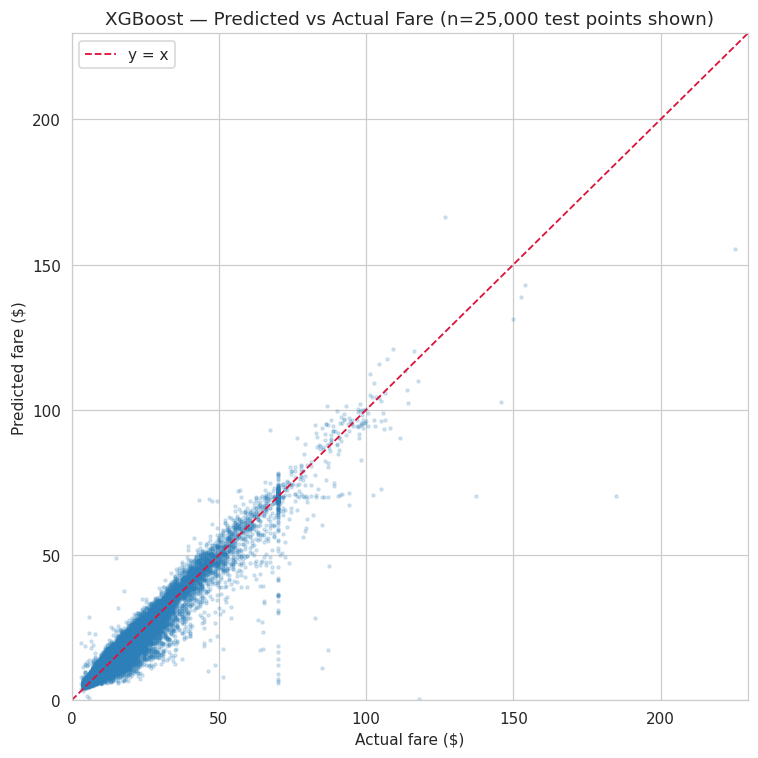

In [ ]:
# random subsample so scatter is readable

plot_n = 25_000

idx = np.random.RandomState(SEED).choice(len(y_test), size=min(plot_n, len(y_test)), replace=False)

y_t  = np.asarray(y_test)[idx]
y_p  = y_pred_xgb[idx]

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_t, y_p, s=4, alpha=0.18, color="#2c7fb8")

# y = x reference line so over- and under-prediction are visually obvious

lim_max = max(y_t.max(), y_p.max()) * 1.02
ax.plot([0, lim_max], [0, lim_max], color="crimson", linestyle="--", linewidth=1.2, label="y = x")

ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)
ax.set_xlabel("Actual fare ($)")
ax.set_ylabel("Predicted fare ($)")
ax.set_title(f"XGBoost — Predicted vs Actual Fare (n={len(idx):,} test points shown)")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fare_xgb_pred_vs_actual.png")
plt.show()


## 13. Residuals — Deck Artifact #2b (secondary)

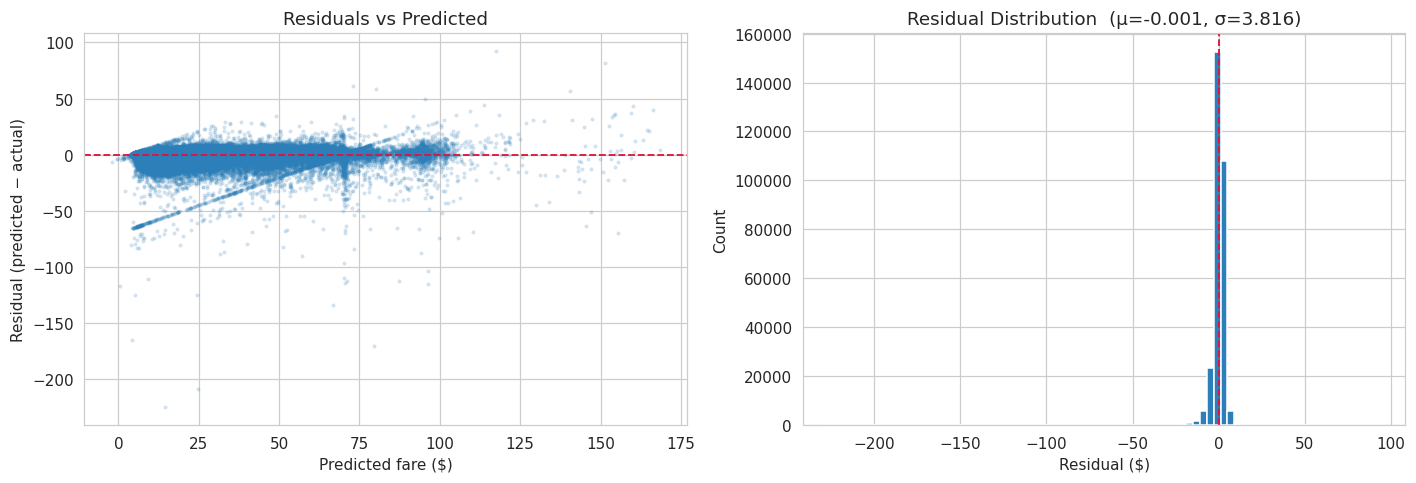

In [ ]:
resid = y_pred_xgb - np.asarray(y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# residuals v predicted, looking for non-random structure (heteroscedasticity, missed nonlinearity)

axes[0].scatter(y_pred_xgb, resid, s=3, alpha=0.15, color="#2c7fb8")
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted fare ($)")
axes[0].set_ylabel("Residual (predicted − actual)")
axes[0].set_title("Residuals vs Predicted")

# residual distribution

axes[1].hist(resid, bins=80, color="#2c7fb8", edgecolor="white")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution  (μ={resid.mean():.3f}, σ={resid.std():.3f})")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fare_xgb_residuals.png")
plt.show()


## 14. Feature Importance — Deck Artifact #3

XGBoost gives importance per *transformed* column, but after one-hot encoding each category becomes its own column (e.g., `pickup_hour_0`, `pickup_hour_1`, …). 


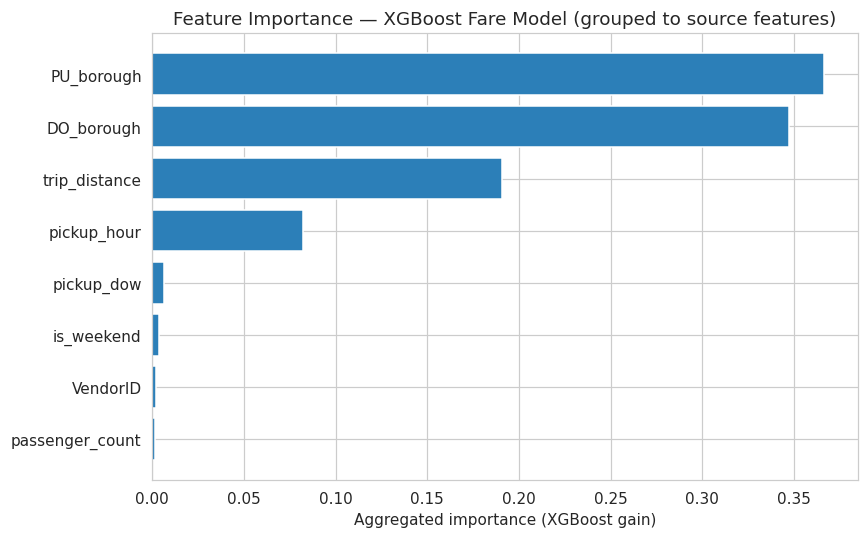

,importance
source,
PU_borough,0.3666
DO_borough,0.3471
trip_distance,0.1910
pickup_hour,0.0820
pickup_dow,0.0062
is_weekend,0.0035
VendorID,0.0020
passenger_count,0.0016


In [ ]:
# fitted estimators out of the pipeline

fitted_prep  = xgb_pipe.named_steps["prep"]
fitted_model = xgb_pipe.named_steps["model"]


# feature names, in order

feature_names = fitted_prep.get_feature_names_out()
importances   = fitted_model.feature_importances_


imp_df = pd.DataFrame({"transformed": feature_names, "importance": importances})

def source_of(transformed_name: str) -> str:



    name = transformed_name.split("__", 1)[1]

    for src in ALL_FEATURES:

        if name == src or name.startswith(src + "_"):
            return src
        
    return name  

imp_df["source"] = imp_df["transformed"].map(source_of)

grouped = (
    imp_df.groupby("source")["importance"]
    .sum()
    .sort_values(ascending=True)   # ascending so largest at top
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(grouped.index, grouped.values, color="#2c7fb8")
ax.set_xlabel("Aggregated importance (XGBoost gain)")
ax.set_title("Feature Importance — XGBoost Fare Model (grouped to source features)")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fare_xgb_feature_importance.png")

plt.show()

grouped.sort_values(ascending=False).to_frame("importance").round(4)


## 15. Summary

*Preliminary Results*


In [ ]:
lift_pct = (rmse_lin - rmse_xgb) / rmse_lin * 100

print("=" * 60)
print(" PRELIMINARY RESULTS — FARE AMOUNT")
print("=" * 60)
print(f" Sample            : {len(sample):,} rows (stratified hour × borough)")
print(f" Train / Test      : {len(X_train):,} / {len(X_test):,}")
print()
print(f" Linear Regression : RMSE ${rmse_lin:.2f} | MAE ${mae_lin:.2f} | R² {r2_lin:.3f}")
print(f" XGBoost           : RMSE ${rmse_xgb:.2f} | MAE ${mae_xgb:.2f} | R² {r2_xgb:.3f}")
print()
print(f" XGBoost reduces RMSE by {lift_pct:.1f}% over the linear baseline.")
print()

top3 = grouped.sort_values(ascending=False).head(3)

print(" Top-3 features (by XGBoost gain):")

for name, val in top3.items():
    print(f"   • {name:<20} {val:.3f}")
    
print()
print(f" Figures saved to : {FIGURE_DIR}")
print(f" Metrics saved to : {METRICS_DIR}")


 PRELIMINARY RESULTS — FARE AMOUNT
 Sample            : 1,499,995 rows (stratified hour × borough)
 Train / Test      : 1,199,996 / 299,999

 Linear Regression : RMSE $4.43 | MAE $2.69 | R² 0.929
 XGBoost           : RMSE $3.82 | MAE $2.12 | R² 0.947

 XGBoost reduces RMSE by 13.8% over the linear baseline.

 Top-3 features (by XGBoost gain):
   • PU_borough           0.367
   • DO_borough           0.347
   • trip_distance        0.191

 Figures saved to : /content/drive/MyDrive/DSCI 592/baseline_fare/figures
 Metrics saved to : /content/drive/MyDrive/DSCI 592/baseline_fare/metrics


## 16. Diagnostic

In case of outlier, concrete read on what's actually causing the worst misses, top-20 test rows by absolute residual along with their feature context.

In [ ]:
worst_n = 20

y_test_arr = y_test.to_numpy()
abs_resid  = np.abs(y_pred_xgb - y_test_arr)


worst_idx = np.argsort(abs_resid)[-worst_n:][::-1]

worst = X_test.iloc[worst_idx].copy()
worst.insert(0, "predicted_fare", np.round(y_pred_xgb[worst_idx], 2))
worst.insert(0, "actual_fare",    np.round(y_test_arr[worst_idx], 2))
worst.insert(0, "residual",       np.round(y_pred_xgb[worst_idx] - y_test_arr[worst_idx], 2))
worst = worst.reset_index(drop=True)

worst.to_csv(METRICS_DIR / "fare_worst_residuals.csv", index=False)
print(f"Top {worst_n} test-set misses by |residual| — saved to fare_worst_residuals.csv\n")
worst

Top 20 test-set misses by |residual| — saved to fare_worst_residuals.csv



,residual,actual_fare,predicted_fare,trip_distance,passenger_count,pickup_hour,pickup_dow,is_weekend,PU_borough,DO_borough,VendorID
0,-225.43,240.0,14.570000,0.60,4.0,23,6,1,Queens,Queens,2
1,-209.37,234.0,24.629999,4.80,1.0,7,0,0,Queens,Queens,2
2,-170.44,250.0,79.559998,55.65,2.0,0,6,1,Unknown,Unknown,2
3,-165.65,170.0,4.350000,0.20,1.0,3,6,1,Manhattan,Manhattan,1
4,-134.26,201.1,66.839996,13.90,2.0,16,0,0,Manhattan,Manhattan,2
5,-125.47,150.0,24.530001,0.24,1.0,5,6,1,Manhattan,Manhattan,2
6,-124.89,130.0,5.110000,0.48,1.0,1,4,0,Manhattan,Manhattan,2
7,-117.61,118.0,0.390000,0.16,1.0,13,6,1,Unknown,Unknown,2
8,-115.57,212.0,96.430000,39.47,1.0,16,6,1,Queens,Brooklyn,2
9,-114.35,184.7,70.349998,34.53,6.0,15,4,0,Queens,Manhattan,2


## 17. Diagnostic — Per-Borough Fare-per-Mile

The borough-dominance in XGBoost's feature importance (PU_borough + DO_borough = 71% of total gain). Provide empirical evidence behind the *"borough encodes fare regime"* interpretation: $/mile varies materially across PU × DO pairs because of congestion-zone surcharges, airport flat rates, and traffic-driven per-minute meter charges. The heatmap shows the gradient that XGBoost is exploiting.

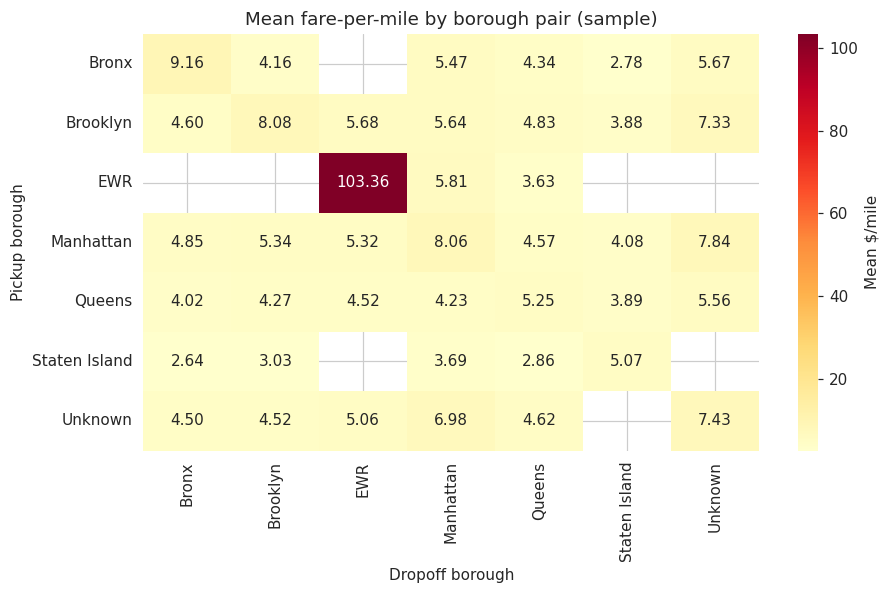

Top borough pairs by $/mile (≥100 trips):


,PU_borough,DO_borough,trips,mean_fare_per_mile,mean_distance_mi,mean_fare
0,Bronx,Bronx,948,9.16,3.28,21.55
1,Brooklyn,Brooklyn,3795,8.08,2.93,18.44
2,Manhattan,Manhattan,1197740,8.06,2.00,14.13
3,Manhattan,Unknown,2608,7.84,2.57,16.31
4,Unknown,Unknown,10121,7.43,3.72,20.48
5,Unknown,Manhattan,2111,6.98,4.66,23.66
6,Brooklyn,Manhattan,2701,5.64,6.54,32.02
7,Queens,Unknown,241,5.56,14.11,58.74
8,Bronx,Manhattan,687,5.47,7.91,33.18
9,Manhattan,Brooklyn,30781,5.34,6.39,32.34


In [ ]:
bdf = sample[[COL["pu_borough"], COL["do_borough"], COL["trip_distance"], TARGET]].copy()
bdf = bdf[bdf[COL["trip_distance"]] >= 0.5]
bdf["fare_per_mile"] = bdf[TARGET] / bdf[COL["trip_distance"]]



dpm = (
    bdf.groupby([COL["pu_borough"], COL["do_borough"]])
       .agg(
           trips=("fare_per_mile", "size"),
           mean_fare_per_mile=("fare_per_mile", "mean"),
           mean_distance_mi=(COL["trip_distance"], "mean"),
           mean_fare=(TARGET, "mean"),
       )
       .reset_index()
)

dpm = (
    dpm[dpm["trips"] >= 100]
      .round({"mean_fare_per_mile": 2, "mean_distance_mi": 2, "mean_fare": 2})
      .sort_values("mean_fare_per_mile", ascending=False)
      .reset_index(drop=True)
)

dpm.to_csv(METRICS_DIR / "fare_per_mile_by_borough_pair.csv", index=False)




heat = bdf.pivot_table(
    index=COL["pu_borough"],
    columns=COL["do_borough"],
    values="fare_per_mile",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "Mean $/mile"}, ax=ax)

ax.set_xlabel("Dropoff borough")
ax.set_ylabel("Pickup borough")

ax.set_title("Mean fare-per-mile by borough pair (sample)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fare_per_mile_borough_heatmap.png")

plt.show()

print(f"Top borough pairs by $/mile (≥100 trips):")

dpm.head(15)

## 16. Next Steps

**Modeling:**
- Add LightGBM as a third model — drop-in swap for the XGBoost cell.
- Hyperparameter tuning with Optuna.
- Try cyclical encoding for `pickup_hour` (sin/cos) and compare against one-hot.
- Move from `pickup_borough` to full `PULocationID` (263 zones) — use XGBoost's native categorical support (`enable_categorical=True`) to handle the cardinality cleanly.
- SHAP values for global + local interpretability.

**Pipeline / repo:**
- Lift the preprocessing + training logic out of this notebook into `src/baseline_fare.py` once it stabilizes.
- Commit the saved metrics JSON to `models/fare_baseline/`.
- `fare_baseline_metrics.csv` → metrics table on the Preliminary Results slide.
- `fare_xgb_pred_vs_actual.png` → main visual.
- `fare_xgb_feature_importance.png` → secondary visual / talking-point anchor.

